Purpose
-------
    Assess biogeochemical fields from ACCESS-OM2-WOMBATmid
    
    We use monthly climatologies for assessment (not specific years)
    
    The fields we are assessing are:
        1  - Surface NO3 at the equatorial band    --> World Ocean Atlas 2023 
        2  - Surface Silicic acid globally         --> World Ocean Atlas 2023 
        3  - Surface DOC concentration globally    --> Panaoitis et al. (2025)
        4  - Surface dFe globally                  --> Huang et al. 2022 Frontiers in Marine Science
        5  - Surface Chlorophyll                   --> Sauzede et al. (2016 JGR: Oceans)
        6  - Depth of max Chlorophyll              --> Sauzede et al. (2016 JGR: Oceans)
        7  - Net Primary Production                --> Carbon-based productivity model (CbPM) 
        8  - Primary nutrient limitation (N or Fe) --> Browning & Moore 2023 Nature Communications
        9  - Air-sea CO2 flux (Southern Ocean)     --> Chau et al. (2022)
        10 - Sinking POC fluxes                    --> Mouw et al. (2016)
        11 - Sinking PIC fluxes                    --> Mouw et al. (2016)
        12 - Sinking BSi fluxes                    --> Mouw et al. (2016)
        13 - Fe:C ratios of phytoplankton          --> Twining et al. (2021)
        14 - Si:C ratios of diatoms                --> Twining et al. (2021)
        15 - fraction of microphytoplankton        --> Sathyendranath et al. (2020)
        16 - NH4:DIN - pNH4:pNPP ratio             --> Buchanan et al. (2025)
        
        

## imports

In [1]:
import sys
import os

import numpy as np
import pandas as pd
import xarray as xr
import scipy as sci
import h5py as h5

import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo
from cmocean.tools import lighten

# regridding package
import xesmf as xe

# statistics package
import skill_metrics as sm

# fit b-values
from scipy.optimize import curve_fit


# print versions of packages
print("python version =",sys.version[:5])
print("numpy version =", np.__version__)
print("pandas version =", pd.__version__)
print("xarray version =", xr.__version__)
print("scipy version =", sci.__version__)
print("h5py version =", h5.__version__)
print("matplotlib version =", sys.modules[plt.__package__].__version__)
print("cmocean version =", sys.modules[cmo.__package__].__version__)
print("cartopy version =", sys.modules[ccrs.__package__].__version__)
print("xesmf version =", xe.__version__)


moddir = "/g/data/vn19/pjb581/WOMBATmid-Optimization/SOTSexps/"
obsdir = "/g/data/vn19/pjb581/WOMBATmid-Optimization/data/observations"
os.chdir(obsdir)


python version = 3.10.
numpy version = 2.2.5
pandas version = 2.3.3
xarray version = 2025.4.0
scipy version = 1.15.3
h5py version = 3.15.1
matplotlib version = 3.10.6
cmocean version = v3.0.3
cartopy version = 0.24.1
xesmf version = 0.8.10


In [2]:
import warnings
warnings.filterwarnings('ignore')

# start up a dask client

In [3]:
import dask
from dask.distributed import Client, LocalCluster
cluster = LocalCluster(n_workers=28, threads_per_worker=1, memory_limit="8GB")
client  = Client(cluster)
client  # shows dashboard link



Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 208.62 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44611,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45071,Total threads: 1
Dashboard: /proxy/37109/status,Memory: 7.45 GiB
Nanny: tcp://127.0.0.1:46101,


## load data

In [4]:
%%time

os.chdir(obsdir + "/SOTS_data/")

bottle_data = xr.open_dataset("sots_monthly_climatology.nc").squeeze()
pco2_data = xr.open_dataset("sots_sofs_pco2_monthly_climatology.nc").squeeze()
chl_data = xr.open_dataset("sots_chl_30m_monthly_climatology.nc").squeeze()
zoo_data = xr.open_dataset("maredat_zoo.nc").squeeze()
bac_data = pd.read_csv("TAN1810_Bacteria_Salp_biomass_converted_mmolC_m3.csv")

### cut out depths > 500 metres
bottle_data = bottle_data.sel(depth=slice(0,500))
zoo_data = zoo_data.sel(DEPTH=slice(0,500))

### Bacterial data
bac_data = bac_data[['Depth water [m]','Bact C [mmol C/m**3] (20 fg C/cell)']]
bac_data = bac_data.sort_values(by='Depth water [m]', ascending=True)
bac_data = bac_data.rename(columns={'Depth water [m]':'depth', 'Bact C [mmol C/m**3] (20 fg C/cell)':'bac'})
bac_data_mean = bac_data.groupby('depth', as_index=False).mean()
bac_data_std = bac_data.groupby('depth', as_index=False).std()
bac_data_mean
bac_data_smooth = pd.DataFrame({
    'depth':bac_data_mean['depth'].values, 
    'mean':bac_data_mean['bac'].values, 
    'std':bac_data_std['bac'].values
})
bac_data

### Argo data
argo_data = xr.open_dataset("ARGO_SOTS.nc").squeeze()
argo_data


CPU times: user 557 ms, sys: 170 ms, total: 727 ms
Wall time: 1.52 s


<xarray.Dataset> Size: 444kB
Dimensions:   (pressure: 1501, month: 12)
Coordinates:
  * pressure  (pressure) int64 12kB 0 1 2 3 4 5 ... 1496 1497 1498 1499 1500
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    POC       (pressure, month) float64 144kB ...
    CHL       (pressure, month) float64 144kB ...
    NO3       (pressure, month) float64 144kB ...

In [5]:
%%time

# Monthly coordinate
months = np.arange(1, 13)

# Seasonal b1 cycle
# High in peak summer, low in peak winter.
# For Southern Hemisphere:
# peak summer = January/February-ish
# peak winter = July/August-ish
b1_max = 1.5
b1_min = 0.7

b1_mean = (b1_max + b1_min) / 2
b1_amp  = (b1_max - b1_min) / 2

# Peak at month 1, minimum at month 7
b1 = b1_mean + b1_amp * np.cos(2 * np.pi * (months - 1) / 12)

# Constant b2
b2 = np.full_like(b1, 0.2, dtype=float)

# Difference
b1_minus_b2 = b1 - b2

# Build dataset
ideal_monthly = xr.Dataset(
    {
        "b1_bpl": ("month", b1),
        "b2_bpl": ("month", b2),
        "b1_minus_b2": ("month", b1_minus_b2),
    },
    coords={
        "month": months
    }
)

ideal_monthly

CPU times: user 725 μs, sys: 416 μs, total: 1.14 ms
Wall time: 1.14 ms


<xarray.Dataset> Size: 384B
Dimensions:      (month: 12)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    b1_bpl       (month) float64 96B 1.5 1.446 1.3 1.1 0.9 ... 0.9 1.1 1.3 1.446
    b2_bpl       (month) float64 96B 0.2 0.2 0.2 0.2 0.2 ... 0.2 0.2 0.2 0.2 0.2
    b1_minus_b2  (month) float64 96B 1.3 1.246 1.1 0.9 0.7 ... 0.7 0.9 1.1 1.246

## Assess the model fit to the observations

CPU times: user 421 ms, sys: 124 ms, total: 545 ms
Wall time: 1.45 s


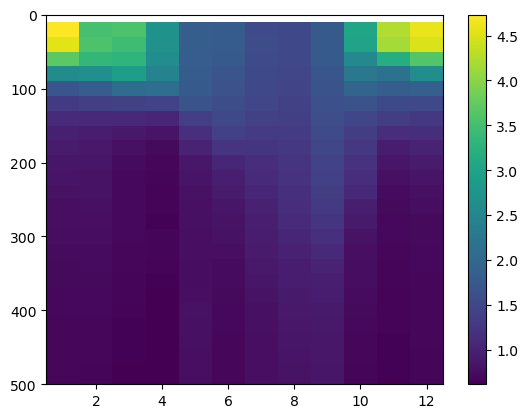

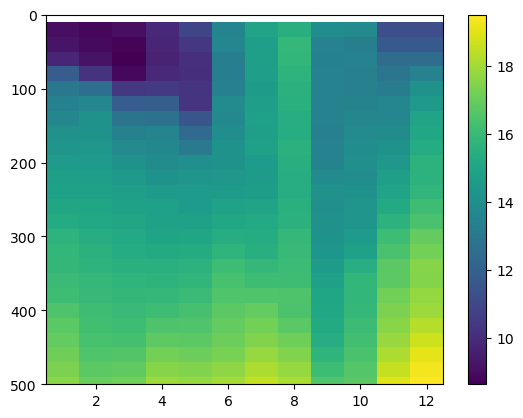

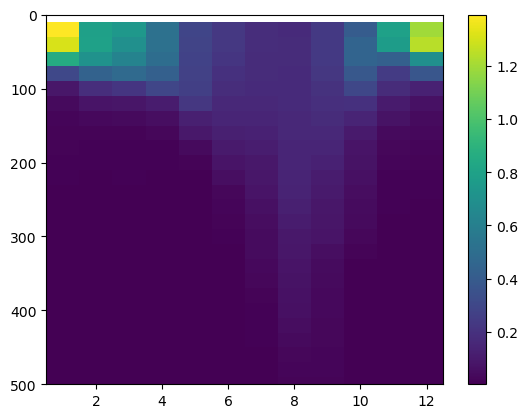

In [6]:
%%time

target_depth = bottle_data.depth
argo_data_obsgrid = argo_data.interp(pressure=target_depth)
argo_data_obsgrid = argo_data_obsgrid.where(argo_data_obsgrid.depth > 10.0, other=np.nan)

plt.figure()
plt.pcolormesh(argo_data_obsgrid.month, argo_data_obsgrid.depth, argo_data_obsgrid['POC']*0.5/12.0)
plt.ylim(500,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(argo_data_obsgrid.month, argo_data_obsgrid.depth, argo_data_obsgrid['NO3'])
plt.ylim(500,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(argo_data_obsgrid.month, argo_data_obsgrid.depth, argo_data_obsgrid['CHL'])
plt.ylim(500,0)
plt.colorbar()


In [7]:
print("put all the observations into a dictionary for iteration")
obsdata = {
    'pco2': pco2_data['pco2_sw'],
    'fgco2': pco2_data['co2_flux_mol_m2_y1'] * (-1),
    'nh4': bottle_data['ammonia'], 
    #'no3': bottle_data['nitrate'], 
    'no3': argo_data_obsgrid['NO3'], 
    'sil': bottle_data['silicate'], 
    'dfe': bottle_data['dFe'], 
    #'poc': bottle_data['POC'], 
    'poc': argo_data_obsgrid['POC']*0.5/12, 
    'bac': bac_data.sort_values(by='depth', ascending=True), 
    'micro': zoo_data['micro_mean'].sel(DEPTH=slice(0,500)).mean(dim='DEPTH',skipna=True)/12.0,
    'meso': zoo_data['meso_mean'].sel(DEPTH=slice(0,500)).mean(dim='DEPTH',skipna=True)/12.0,
    #'chl_bottle': bottle_data['chlorophyll_total_mv'],
    'chl_bottle': argo_data_obsgrid['CHL'],
    'chl_mooring': chl_data['chlorophyll'],
    'b1mb2': ideal_monthly['b1_minus_b2'],
    'D2L300mD2L50': ideal_monthly['b1_minus_b2']*0.5+2.0
    }


put all the observations into a dictionary for iteration


## plot the observations

In [8]:

os.chdir(moddir + "/figures/")
os.getcwd()


'/g/data/vn19/pjb581/WOMBATmid-Optimization/SOTSexps/figures'

In [9]:
obsdata['bac']

,depth,bac
5,5,1.884050
11,5,1.521490
23,5,1.487590
17,5,1.304600
29,5,1.475510
...,...,...
94,100,NaN
98,100,0.919447
118,120,0.690431
132,120,0.578529


CPU times: user 333 ms, sys: 13.3 ms, total: 347 ms
Wall time: 337 ms


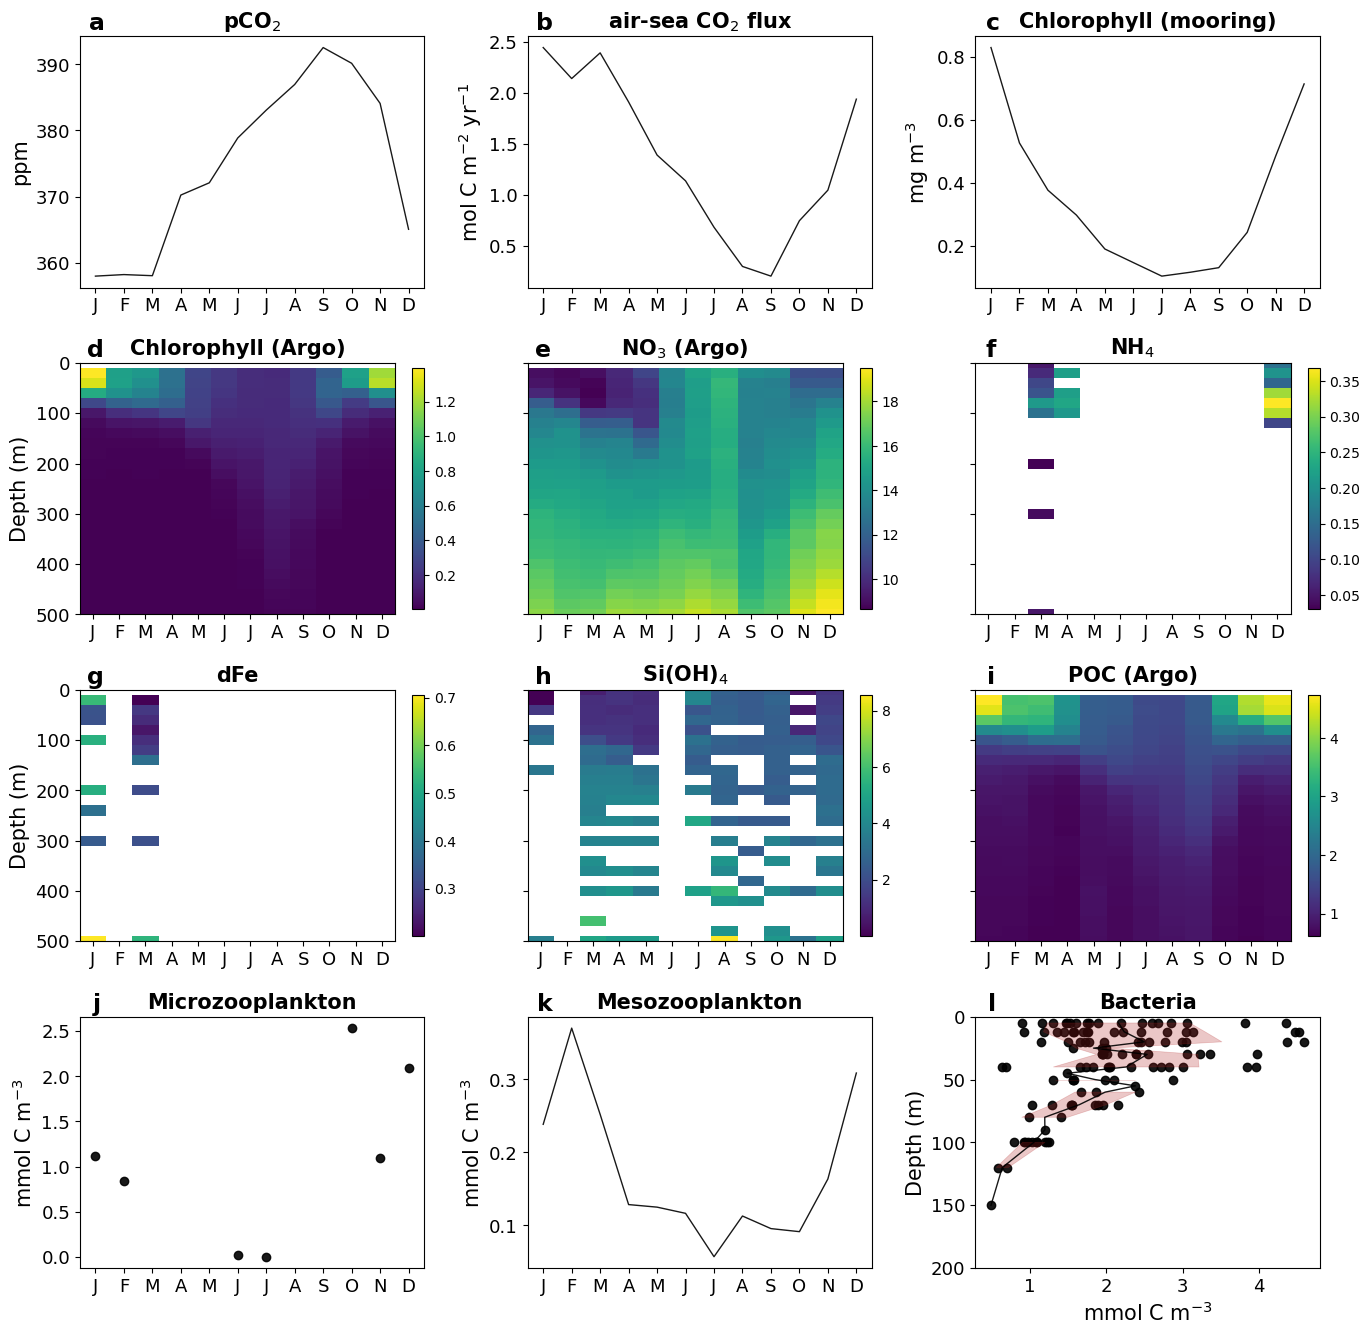

In [10]:
%%time

months = np.arange(1,13,1)
monlab = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
depths = bottle_data['ammonia'].depth
col = ['k', 'firebrick']
lwid = [1.0, 0.5]
alf = [0.9, 0.25]


fstic = 13
fslab = 15

fig = plt.figure(figsize=(16,16))
gs = GridSpec(4,3)

ax1 = plt.subplot(gs[0,0])
ax2 = plt.subplot(gs[0,1])
ax3 = plt.subplot(gs[0,2])
ax4 = plt.subplot(gs[1,0])
ax5 = plt.subplot(gs[1,1])
ax6 = plt.subplot(gs[1,2])
ax7 = plt.subplot(gs[2,0])
ax8 = plt.subplot(gs[2,1])
ax9 = plt.subplot(gs[2,2])
ax10 = plt.subplot(gs[3,0])
ax11 = plt.subplot(gs[3,1])
ax12 = plt.subplot(gs[3,2])
#ax13 = plt.subplot(gs[4,0])
#ax14 = plt.subplot(gs[4,1])

ax1.tick_params(labelsize=fstic)
ax2.tick_params(labelsize=fstic)
ax3.tick_params(labelsize=fstic)
ax4.tick_params(labelsize=fstic)
ax5.tick_params(labelsize=fstic, labelleft=False)
ax6.tick_params(labelsize=fstic, labelleft=False)
ax7.tick_params(labelsize=fstic)
ax8.tick_params(labelsize=fstic, labelleft=False)
ax9.tick_params(labelsize=fstic, labelleft=False)
ax10.tick_params(labelsize=fstic)
ax11.tick_params(labelsize=fstic)
ax12.tick_params(labelsize=fstic)
#ax13.tick_params(labelsize=fstic)
#ax14.tick_params(labelsize=fstic)

p1 = ax1.plot(months,obsdata['pco2'], color=col[0], linewidth=lwid[0], alpha=alf[0])
p2 = ax2.plot(months,obsdata['fgco2'], color=col[0], linewidth=lwid[0], alpha=alf[0])
p3 = ax3.plot(months,obsdata['chl_mooring'], color=col[0], linewidth=lwid[0], alpha=alf[0])
p4 = ax4.pcolormesh(months,depths,obsdata['chl_bottle'])
p5 = ax5.pcolormesh(months,depths,obsdata['no3'])
p6 = ax6.pcolormesh(months,depths,obsdata['nh4'])
p7 = ax7.pcolormesh(months,depths,obsdata['dfe'])
p8 = ax8.pcolormesh(months,depths,obsdata['sil'])
p9 = ax9.pcolormesh(months,depths,obsdata['poc'])
p10 = ax10.scatter(months,obsdata['micro'], color=col[0], alpha=alf[0])
p11 = ax11.plot(months,obsdata['meso'], color=col[0], linewidth=lwid[0], alpha=alf[0])
p12 = ax12.scatter(obsdata['bac']['bac'], obsdata['bac']['depth'], color=col[0], alpha=alf[0])
p12 = ax12.plot(bac_data_smooth['mean'], bac_data_smooth['depth'], color=col[0], linewidth=lwid[0], alpha=alf[0])
p12 = ax12.fill_betweenx(bac_data_smooth['depth'], 
                         bac_data_smooth['mean'] - bac_data_smooth['std'],
                         bac_data_smooth['mean'] + bac_data_smooth['std'],
                         color=col[1], linewidth=lwid[1], alpha=alf[1])

ax1.set_xticks(months, monlab)
ax2.set_xticks(months, monlab)
ax3.set_xticks(months, monlab)
ax4.set_xticks(months, monlab)
ax5.set_xticks(months, monlab)
ax6.set_xticks(months, monlab)
ax7.set_xticks(months, monlab)
ax8.set_xticks(months, monlab)
ax9.set_xticks(months, monlab)
ax10.set_xticks(months, monlab)
ax11.set_xticks(months, monlab)

ax4.set_ylim(500,0)
ax5.set_ylim(500,0)
ax6.set_ylim(500,0)
ax7.set_ylim(500,0)
ax8.set_ylim(500,0)
ax9.set_ylim(500,0)
#ax10.set_ylim(500,0)
#ax11.set_ylim(500,0)
ax12.set_ylim(200,0)

ax1.set_ylabel("ppm", fontsize=fslab)
ax2.set_ylabel("mol C m$^{-2}$ yr$^{-1}$", fontsize=fslab)
ax3.set_ylabel("mg m$^{-3}$", fontsize=fslab)
ax4.set_ylabel("Depth (m)", fontsize=fslab)
ax7.set_ylabel("Depth (m)", fontsize=fslab)
ax10.set_ylabel("mmol C m$^{-3}$", fontsize=fslab)
ax11.set_ylabel("mmol C m$^{-3}$", fontsize=fslab)
ax12.set_ylabel("Depth (m)", fontsize=fslab)
ax12.set_xlabel("mmol C m$^{-3}$", fontsize=fslab)


ax1.set_title('pCO$_2$', fontweight='bold', fontsize=fslab)
ax2.set_title('air-sea CO$_2$ flux', fontweight='bold', fontsize=fslab)
ax3.set_title('Chlorophyll (mooring)', fontweight='bold', fontsize=fslab)
ax4.set_title('Chlorophyll (Argo)', fontweight='bold', fontsize=fslab)
ax5.set_title('NO$_3$ (Argo)', fontweight='bold', fontsize=fslab)
ax6.set_title('NH$_4$', fontweight='bold', fontsize=fslab)
ax7.set_title('dFe', fontweight='bold', fontsize=fslab)
ax8.set_title('Si(OH)$_4$', fontweight='bold', fontsize=fslab)
ax9.set_title('POC (Argo)', fontweight='bold', fontsize=fslab)
ax10.set_title('Microzooplankton', fontweight='bold', fontsize=fslab)
ax11.set_title('Mesozooplankton', fontweight='bold', fontsize=fslab)
ax12.set_title('Bacteria', fontweight='bold', fontsize=fslab)

cbar4 = plt.colorbar(p4, ax=ax4, orientation='vertical', fraction=0.035, aspect=20)
cbar5 = plt.colorbar(p5, ax=ax5, orientation='vertical', fraction=0.035, aspect=20)
cbar6 = plt.colorbar(p6, ax=ax6, orientation='vertical', fraction=0.035, aspect=20)
cbar7 = plt.colorbar(p7, ax=ax7, orientation='vertical', fraction=0.035, aspect=20)
cbar8 = plt.colorbar(p8, ax=ax8, orientation='vertical', fraction=0.035, aspect=20)
cbar9 = plt.colorbar(p9, ax=ax9, orientation='vertical', fraction=0.035, aspect=20)

xx = 0.05; yy = 1.05
plt.text(xx,yy, 'a', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy, 'b', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy, 'c', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy, 'd', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax4.transAxes)
plt.text(xx,yy, 'e', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax5.transAxes)
plt.text(xx,yy, 'f', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax6.transAxes)
plt.text(xx,yy, 'g', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax7.transAxes)
plt.text(xx,yy, 'h', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax8.transAxes)
plt.text(xx,yy, 'i', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax9.transAxes)
plt.text(xx,yy, 'j', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax10.transAxes)
plt.text(xx,yy, 'k', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax11.transAxes)
plt.text(xx,yy, 'l', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax12.transAxes)

plt.subplots_adjust(hspace=0.3, wspace=0.3)

In [11]:
os.getcwd()

'/g/data/vn19/pjb581/WOMBATmid-Optimization/SOTSexps/figures'

In [13]:
%%time
    
fig.savefig("observational_targets.png", dpi=300, bbox_inches='tight')
fig.savefig("observational_targets_transparent.png", dpi=300, bbox_inches='tight', transparent=True)


CPU times: user 4.27 s, sys: 386 ms, total: 4.65 s
Wall time: 3.94 s
